In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

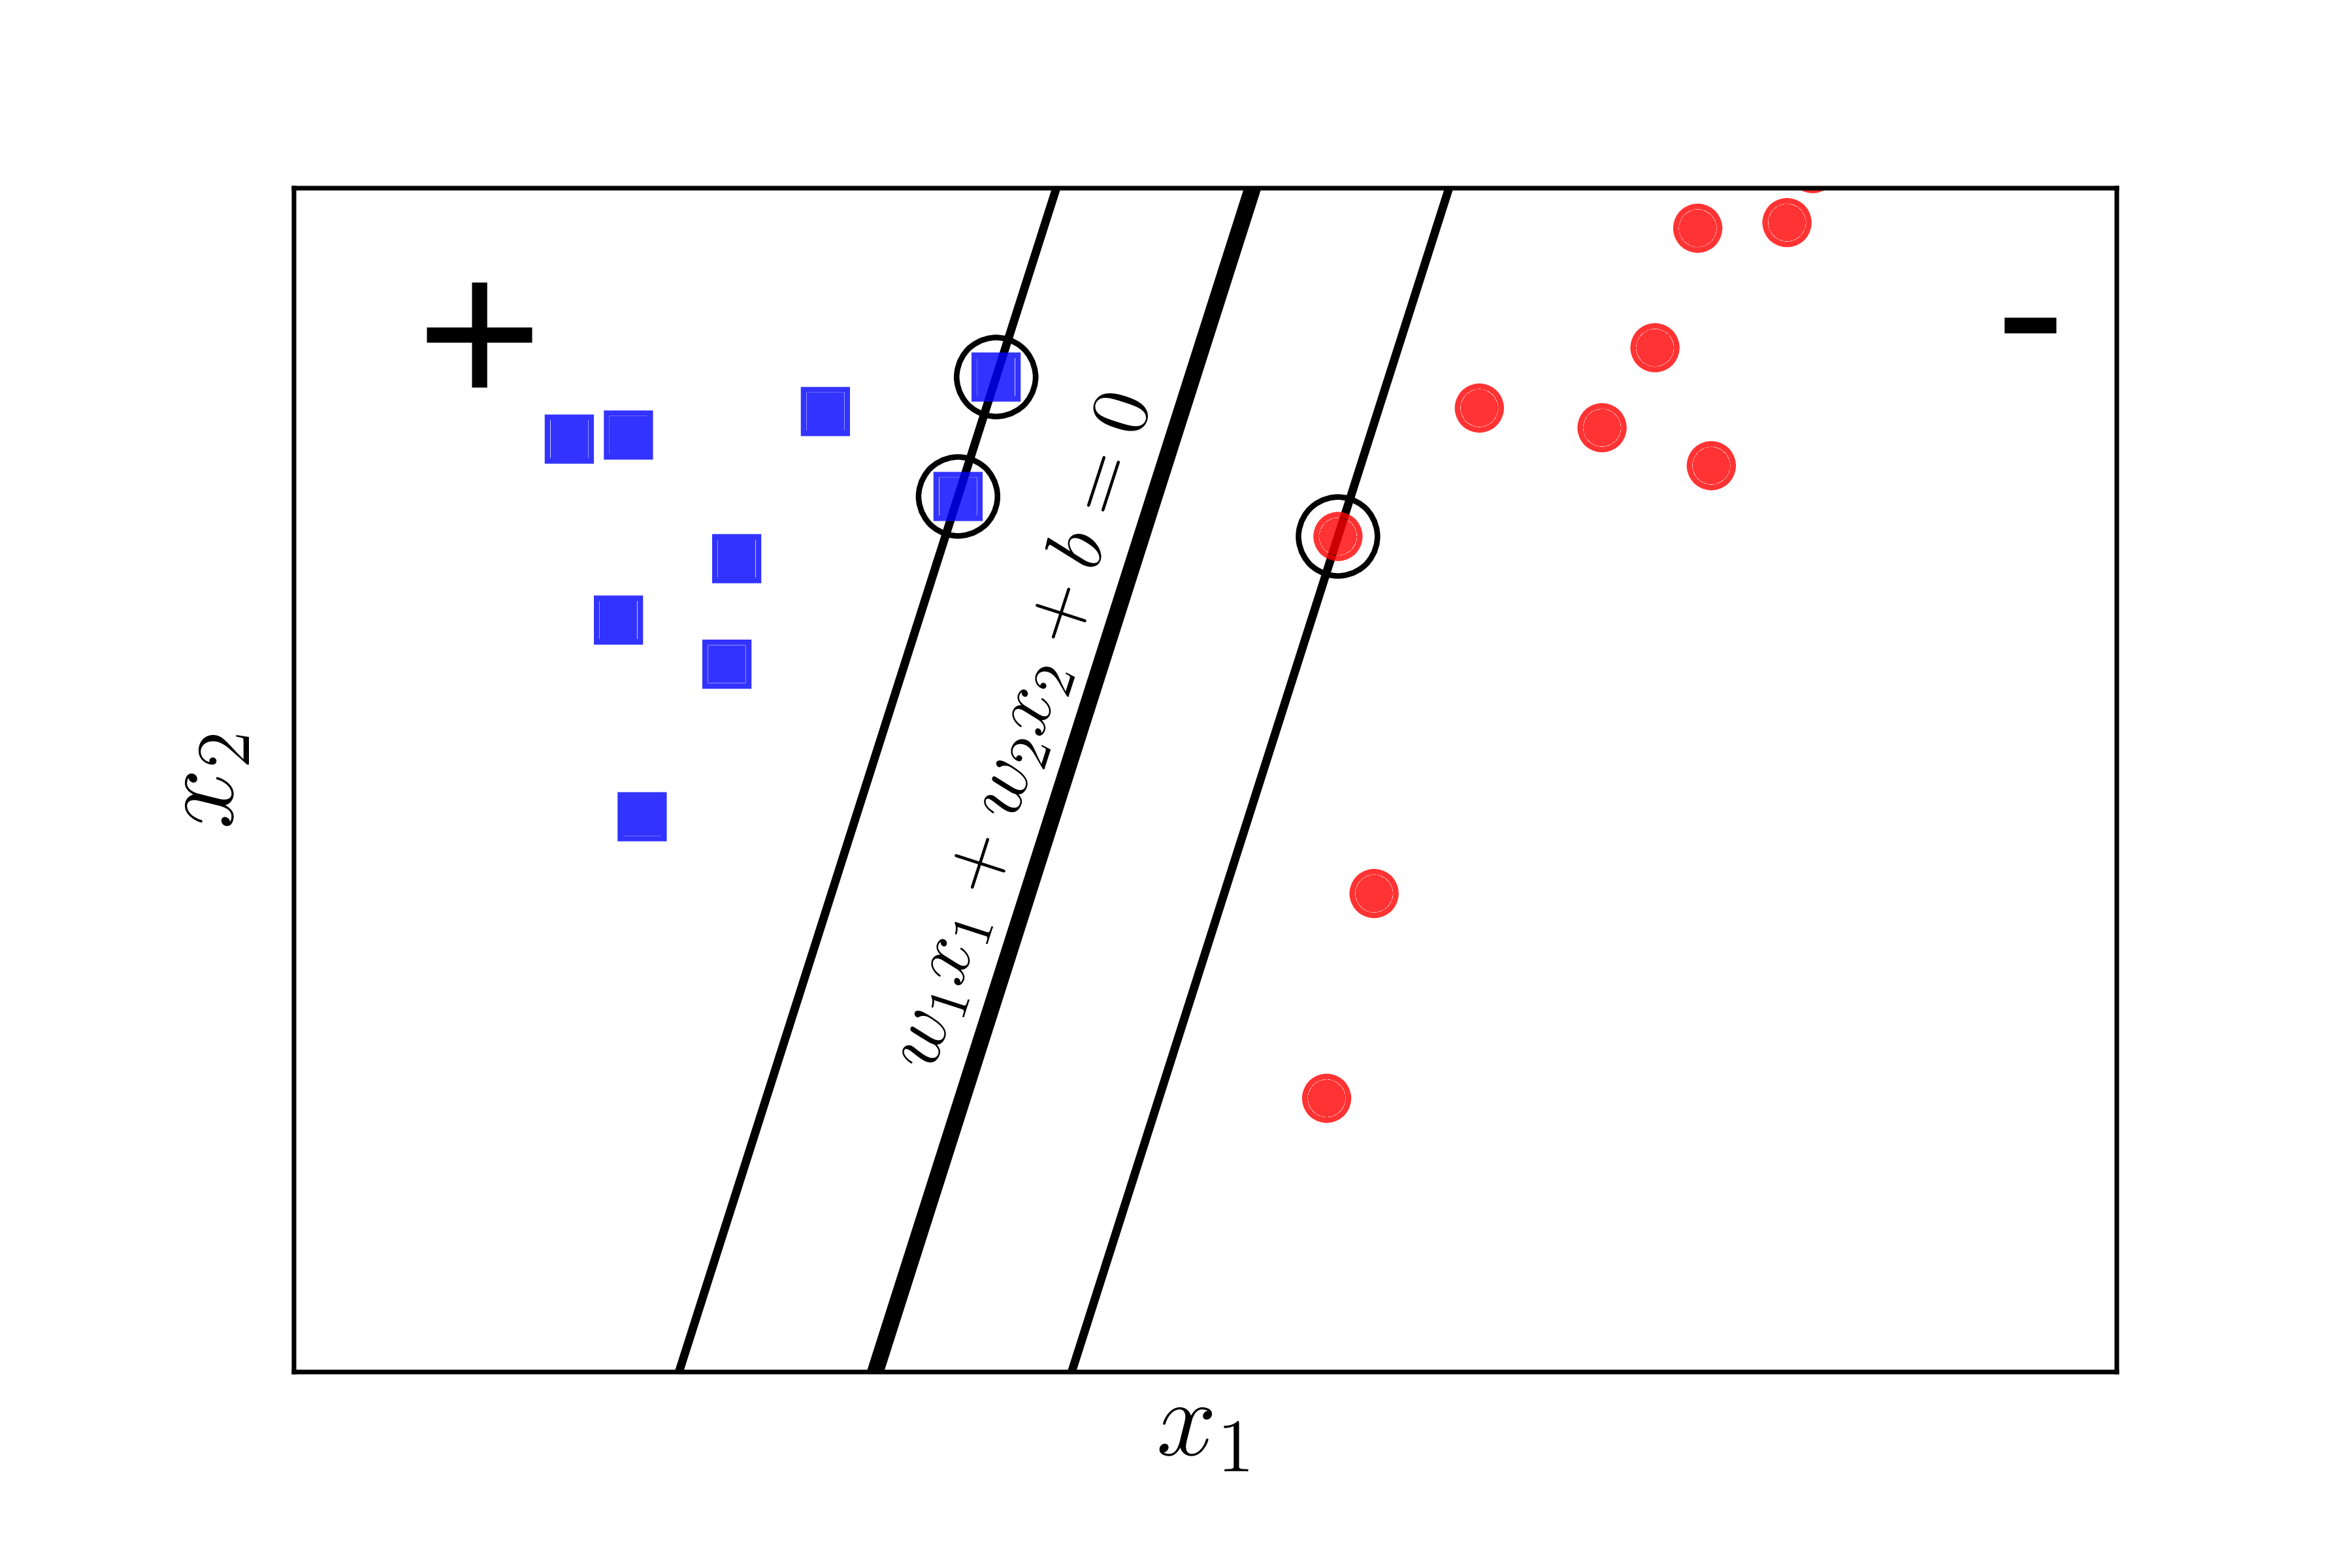


This algorithm focuses on the difference between 2 classes, that is all targets of 2 classes which are near each other. Those targets are near the border and can confuse user which class they belong to
We have the margin that can help us to classify them and this margin will be as wide as posible to be more acccurated

In [2]:
from sklearn import datasets
import warnings
warnings.filterwarnings('ignore')

In [5]:
iris = datasets.load_iris()


In [6]:
df =  pd.DataFrame(data=np.c_[iris['data'],iris['target']],columns=iris['feature_names']+['target'])

In [7]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


In [8]:
from sklearn import metrics

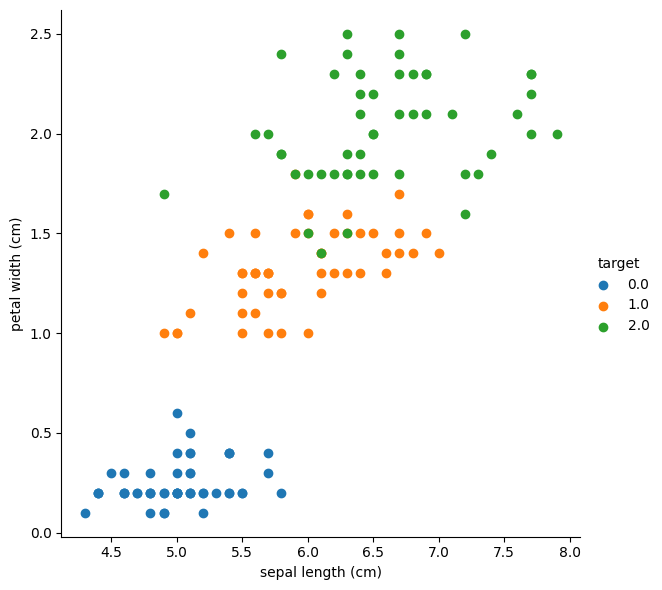

In [13]:
sns.FacetGrid(df,hue='target',height=6).map(plt.scatter,'sepal length (cm)','petal width (cm)').add_legend()


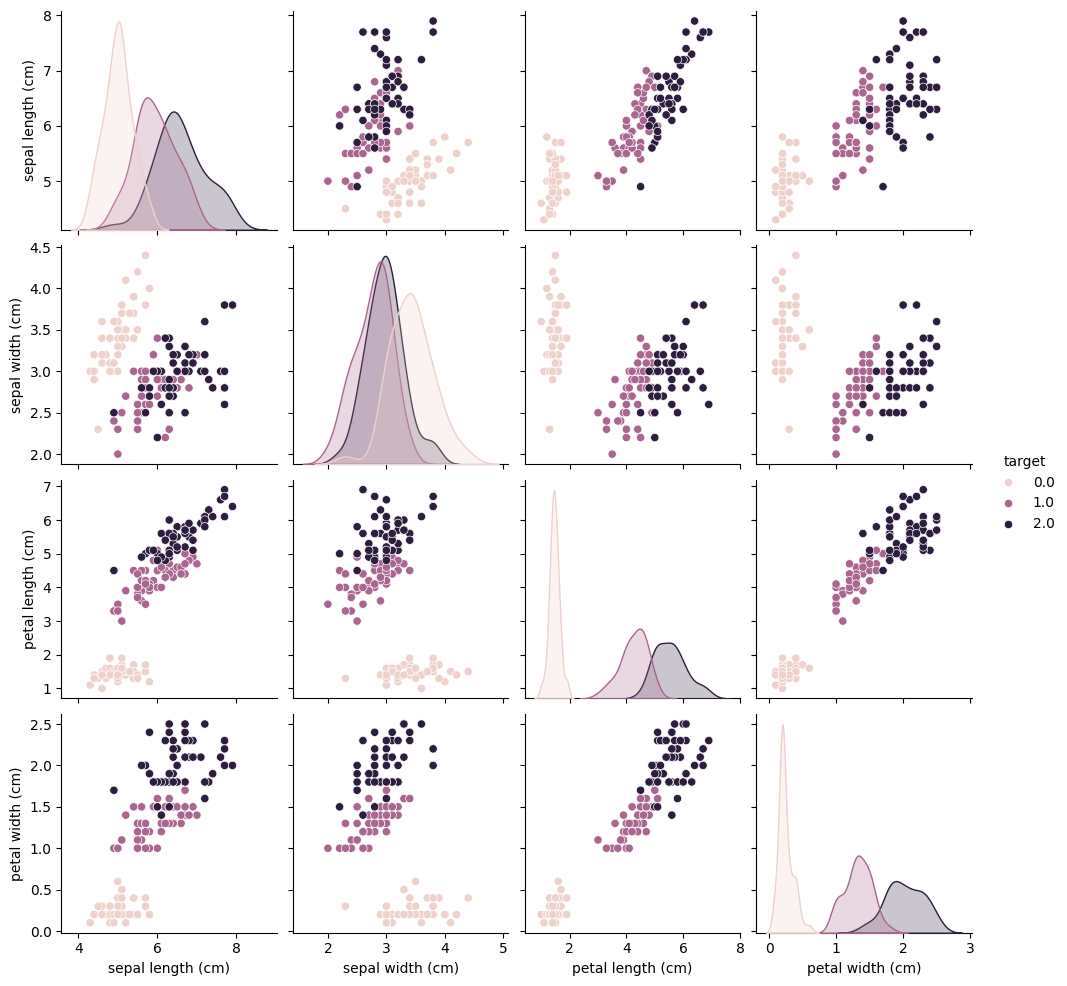

In [19]:
sns.pairplot(df, hue="target")

In [14]:
from sklearn import svm


In [21]:
from sklearn import metrics

In [15]:
x= df.drop('target', axis=1)
y= df['target']

In [ ]:
model = svm.SVC(kernel='linear', C=1.0) # default C=1 means no regularization
#kernels: linear, poly, rbf, sigmoid. poly is polynomial, rbf is radial basis function (gaussian)
model.fit(x,y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
model.score(iris['data'],iris['target'])

0.9933333333333333

In [22]:
expected = iris['target']
predicted = model.predict(iris['data'])
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.98      0.99        50
           2       0.98      1.00      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

[[50  0  0]
 [ 0 49  1]
 [ 0  0 50]]


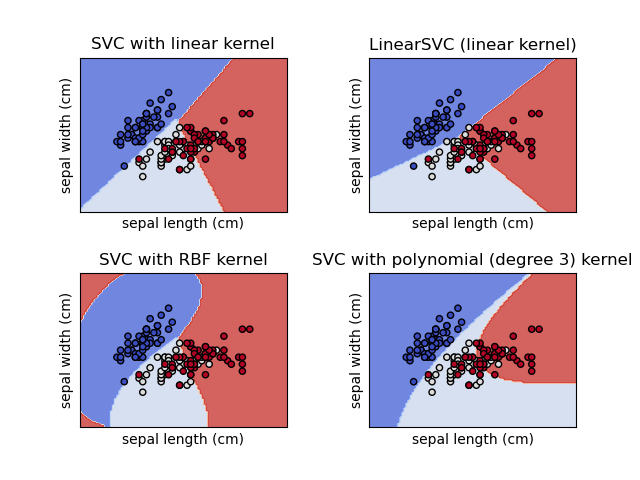

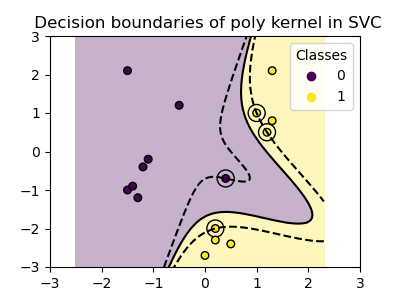

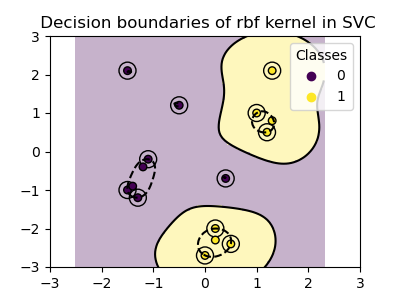

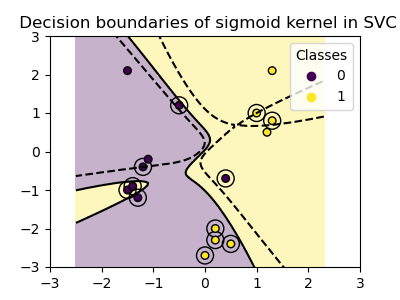

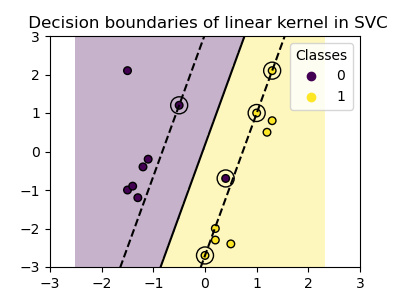

https://scikit-learn.org/stable/modules/svm.html
parameter: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
gamma{‘scale’, ‘auto’} or float, default=’scale’
Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.

if gamma='scale' (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,

if ‘auto’, uses 1 / n_features

if float, must be non-negative

coef0 float, default=0.0
Independent term in kernel function. It is only significant in ‘poly’ and ‘sigmoid’.

In [23]:
model1 = svm.SVC(kernel='rbf', C=1.0) # default C=1 means no regularization
#kernels: linear, poly, rbf, sigmoid. poly is polynomial, rbf is radial basis function (gaussian)
model1.fit(x,y)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [24]:
model1.score(iris['data'],iris['target'])

0.9733333333333334

In [25]:
expected = iris['target']
predicted = model1.predict(iris['data'])
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.96      0.96      0.96        50
           2       0.96      0.96      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150

[[50  0  0]
 [ 0 48  2]
 [ 0  2 48]]


In [26]:
model2 = svm.SVC(kernel='poly', C=1.0) # default C=1 means no regularization
#kernels: linear, poly, rbf, sigmoid. poly is polynomial, rbf is radial basis function (gaussian)
model2.fit(x,y)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
model2.score(iris['data'],iris['target'])

0.9733333333333334

In [28]:
expected = iris['target']
predicted = model2.predict(iris['data'])
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.92      0.96        50
           2       0.93      1.00      0.96        50

    accuracy                           0.97       150
   macro avg       0.98      0.97      0.97       150
weighted avg       0.98      0.97      0.97       150

[[50  0  0]
 [ 0 46  4]
 [ 0  0 50]]


In [29]:
model3 = svm.SVC(kernel='sigmoid', C=1.0) # default C=1 means no regularization
#kernels: linear, poly, rbf, sigmoid. poly is polynomial, rbf is radial basis function (gaussian)
model3.fit(x,y)

,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
model3.score(iris['data'],iris['target']) # Độ chính xác thấp nhất

0.07333333333333333

Kernel phù hợp nhất là Linear